# Exploratory Data Analysis

Dataset
- Online Shoppers Intention

## Dicionário de dados

Administrative", "Administrative Duration", "Informational", "Informational Duration", "Product Related" and "Product Related Duration" represent the number of different types of pages visited by the visitor in that session and total time spent in each of these page categories. 
The values of these features are derived from the URL information of the pages visited by the user and updated in real time when a user takes an action, e.g. moving from one page to another. 

The "Bounce Rate", "Exit Rate" and "Page Value" features represent the metrics measured by "Google Analytics" for each page in the e-commerce site. 
- The value of "Bounce Rate" feature for a web page refers to the percentage of visitors who enter the site from that page and then leave ("bounce") without triggering any other requests to the analytics server during that session. 
- The value of "Exit Rate" feature for a specific web page is calculated as for all pageviews to the page, the percentage that were the last in the session. 
- The "Page Value" feature represents the average value for a web page that a user visited before completing an e-commerce transaction. 

**Esses valores são as médias das `sessions`!**

The "Special Day" feature indicates the closeness of the site visiting time to a specific special day (e.g. Mother’s Day, Valentine's Day) in which the sessions are more likely to be finalized with transaction. The value of this attribute is determined by considering the dynamics of e-commerce such as the duration between the order date and delivery date. For example, for Valentina’s day, this value takes a nonzero value between February 2 and February 12, zero before and after this date unless it is close to another special day, and its maximum value of 1 on February 8. 

The dataset also includes operating system, browser, region, traffic type, visitor type as returning or new visitor, a Boolean value indicating whether the date of the visit is weekend, and month of the year.

## Imports

In [118]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats

pd.set_option("display.max_columns", None)
sns.set_theme(style="darkgrid")
sns.set_palette(sns.color_palette("colorblind6"))

%matplotlib inline

## Dataset

In [119]:
df = pd.read_csv("../data/online_shoppers_intention.csv")
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [120]:
df.shape

(12330, 18)

In [121]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType              12330 no

As colunas `OperatingSystems`, `Browser`, `Region` e `TrafficType` são colunas categórias apesar de terem sido inferidas como `int`.

In [122]:
cat_cols = ["OperatingSystems", "Browser", "Region", "TrafficType"]

df = df.astype({col: "category" for col in cat_cols})

In [123]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Administrative,12330.0,2.315166,3.321784,0.0,0.000000,1.000000,4.000000,27.000000
Administrative_Duration,12330.0,80.818611,176.779107,0.0,0.000000,7.500000,93.256250,3398.750000
Informational,12330.0,0.503569,1.270156,0.0,0.000000,0.000000,0.000000,24.000000
Informational_Duration,12330.0,34.472398,140.749294,0.0,0.000000,0.000000,0.000000,2549.375000
ProductRelated,12330.0,31.731468,44.475503,0.0,7.000000,18.000000,38.000000,705.000000
ProductRelated_Duration,12330.0,1194.746220,1913.669288,0.0,184.137500,598.936905,1464.157214,63973.522230
BounceRates,12330.0,0.022191,0.048488,0.0,0.000000,0.003112,0.016813,0.200000
ExitRates,12330.0,0.043073,0.048597,0.0,0.014286,0.025156,0.050000,0.200000
PageValues,12330.0,5.889258,18.568437,0.0,0.000000,0.000000,0.000000,361.763742
SpecialDay,12330.0,0.061427,0.198917,0.0,0.000000,0.000000,0.000000,1.000000


In [124]:
df.describe(include=["bool", "str", "category"], exclude=["float", "int"]).T

,count,unique,top,freq
Month,12330,10,May,3364
OperatingSystems,12330,8,2,6601
Browser,12330,13,2,7961
Region,12330,9,1,4780
TrafficType,12330,20,2,3913
VisitorType,12330,3,Returning_Visitor,10551
Weekend,12330,2,False,9462
Revenue,12330,2,False,10422


- Todas as colunas tem count == 12330, o que indica que não há nenhum valor nulo.

In [125]:
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [126]:
df.duplicated().sum()

np.int64(125)

- 125 colunas duplicadas

In [127]:
df["Month"].unique()

<StringArray>
['Feb', 'Mar', 'May', 'Oct', 'June', 'Jul', 'Aug', 'Nov', 'Sep', 'Dec']
Length: 10, dtype: str

- Os meses de Janeiro e Abril não constam no dataset.

In [128]:
df["Month"] = df["Month"].map(
    {
        "Feb": 2,
        "Mar": 3,
        "May": 5,
        "June": 6,
        "Jul": 7,
        "Aug": 8,
        "Sep": 9,
        "Oct": 10,
        "Nov": 11,
        "Dec": 12,
    }
)

In [129]:
df["VisitorType"].unique()

<StringArray>
['Returning_Visitor', 'New_Visitor', 'Other']
Length: 3, dtype: str

In [130]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,2,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,2,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,2,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,2,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,2,3,3,1,4,Returning_Visitor,True,False


## Revenue

In [131]:
df["Revenue"].value_counts(normalize=True)

Revenue
False    0.845255
True     0.154745
Name: proportion, dtype: float64

- Variável Alvo altamente desbalanceada.

## Features

### Administrative

In [184]:
df["Administrative"].value_counts(normalize=True)

Administrative
0     0.467802
1     0.109813
2     0.090349
3     0.074209
4     0.062044
5     0.046634
6     0.035036
7     0.027413
8     0.023277
9     0.018248
10    0.012409
11    0.008516
12    0.006975
13    0.004542
14    0.003569
15    0.003082
16    0.001946
17    0.001298
18    0.000973
19    0.000487
24    0.000324
22    0.000324
23    0.000243
21    0.000162
20    0.000162
27    0.000081
26    0.000081
Name: proportion, dtype: float64

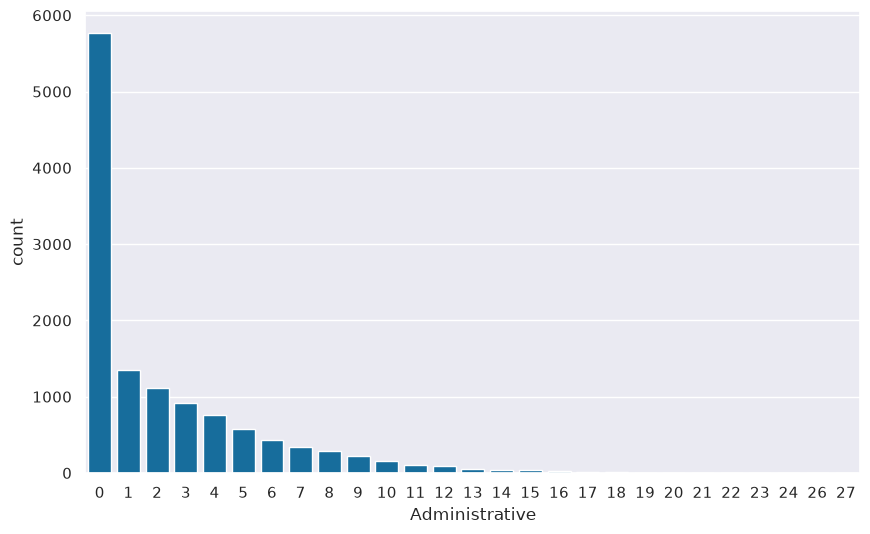

In [133]:
plt.figure(figsize=(10, 6))
sns.countplot(x="Administrative", data=df)
plt.show()

In [134]:
zero_rate = (df["Administrative"] == 0).mean() * 100
positive_vals = df.loc[df["Administrative"] > 0, "Administrative"]

print(f"Taxa de zeros: {zero_rate:.2f}%")
print(
    f"Resumo (> 0): Mediana={positive_vals.median()}, P90={positive_vals.quantile(0.90)}, Max={positive_vals.max()}"
)

Taxa de zeros: 46.78%
Resumo (> 0): Mediana=3.0, P90=9.0, Max=27


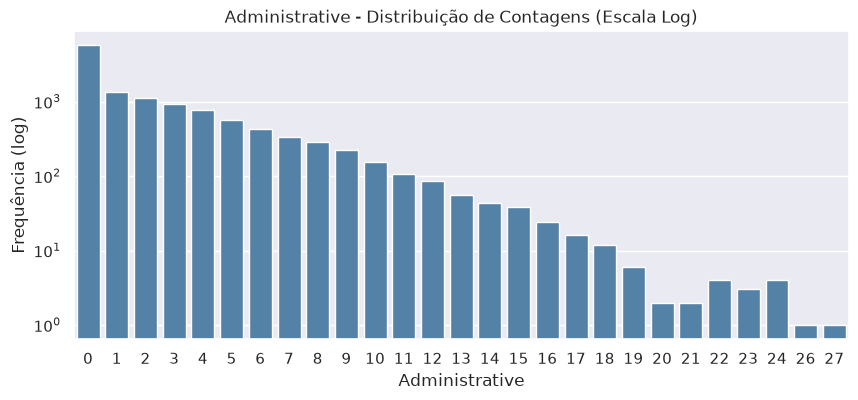

In [135]:
plt.figure(figsize=(10, 4))
ax = sns.countplot(x="Administrative", data=df, color="steelblue")
ax.set_yscale("log")
plt.title("Administrative - Distribuição de Contagens (Escala Log)")
plt.ylabel("Frequência (log)")
plt.show()

### Administrative_Duration

In [136]:
col = df["Administrative_Duration"].dropna()

In [137]:
col.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

count    12330.000000
mean        80.818611
std        176.779107
min          0.000000
1%           0.000000
5%           0.000000
25%          0.000000
50%          7.500000
75%         93.256250
95%        348.266369
99%        830.587041
max       3398.750000
Name: Administrative_Duration, dtype: float64

In [138]:
skew = col.skew()
kurt = col.kurtosis()

q25 = col.quantile(0.25)
q75 = col.quantile(0.75)
iqr = q75 - q25

print(f"Skewness: {skew:.4f}\nKurtosis: {kurt:.4f}\nIQR: {iqr:.4f}")

Skewness: 5.6157
Kurtosis: 50.5567
IQR: 93.2562


In [139]:
limite_inferior = q25 - 1.5 * iqr
limite_superior = q75 + 1.5 * iqr

outliers = df[(col < limite_inferior) | (col > limite_superior)]
print(f"Outliers: {len(outliers)} linhas ({len(outliers) / len(df) * 100:.2f}%)")

Outliers: 1172 linhas (9.51%)


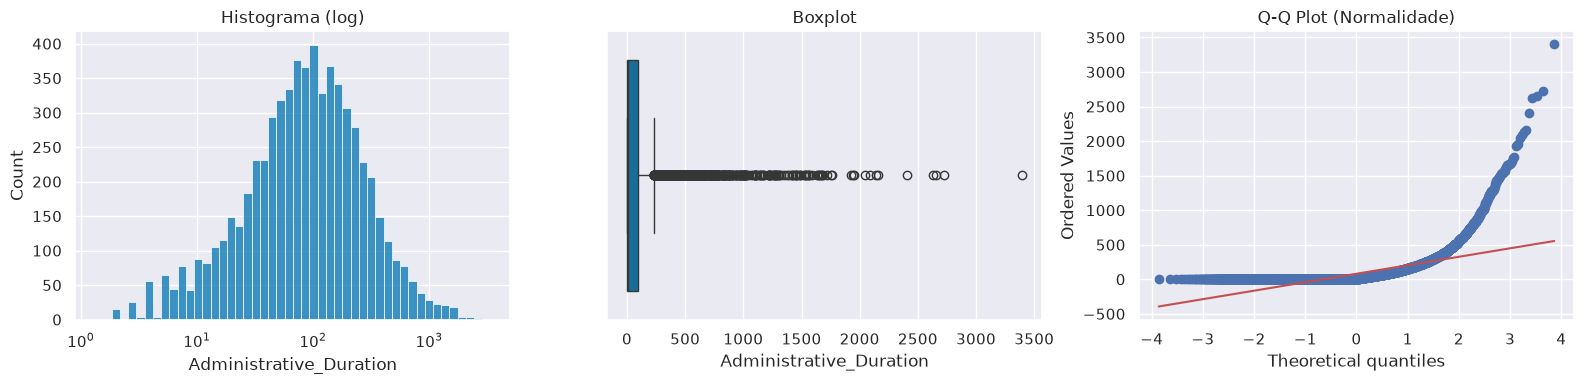

In [140]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(data=df, x=col, ax=axes[0], log_scale=True)
axes[0].set_title("Histograma (log)")

sns.boxplot(x=col, ax=axes[1])
axes[1].set_title("Boxplot")

stats.probplot(col, dist="norm", plot=axes[2])
axes[2].set_title("Q-Q Plot (Normalidade)")

plt.tight_layout()
plt.show()

### Informational

In [141]:
df["Informational"].value_counts(normalize=True)

Informational
0     0.786618
1     0.084428
2     0.059043
3     0.030819
4     0.018005
5     0.008029
6     0.006326
7     0.002920
9     0.001217
8     0.001135
10    0.000568
12    0.000406
14    0.000162
16    0.000081
11    0.000081
24    0.000081
13    0.000081
Name: proportion, dtype: float64

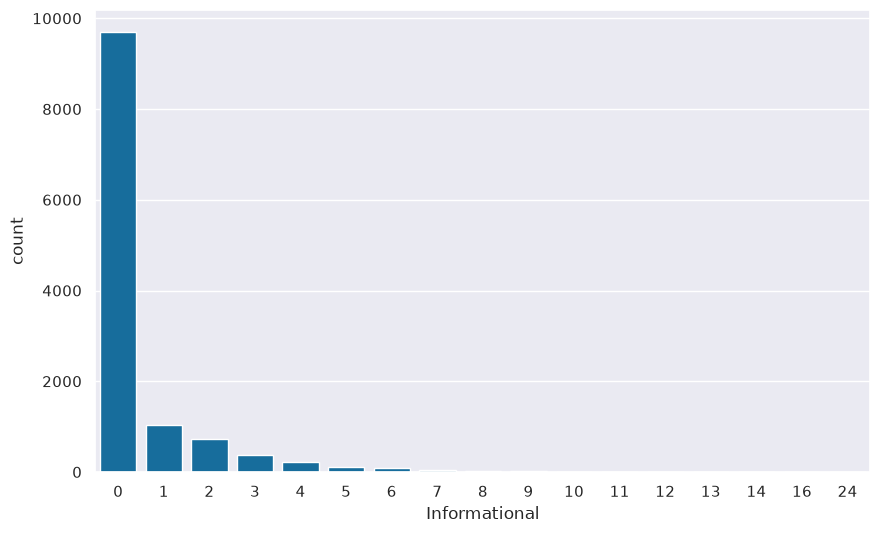

In [142]:
plt.figure(figsize=(10, 6))
sns.countplot(x="Informational", data=df)
plt.show()

In [143]:
zero_rate = (df["Informational"] == 0).mean() * 100
positive_vals = df.loc[df["Informational"] > 0, "Informational"]

print(f"Taxa de zeros: {zero_rate:.2f}%")
print(
    f"Resumo (> 0): Mediana={positive_vals.median()}, P90={positive_vals.quantile(0.90)}, Max={positive_vals.max()}"
)

Taxa de zeros: 78.66%
Resumo (> 0): Mediana=2.0, P90=4.0, Max=24


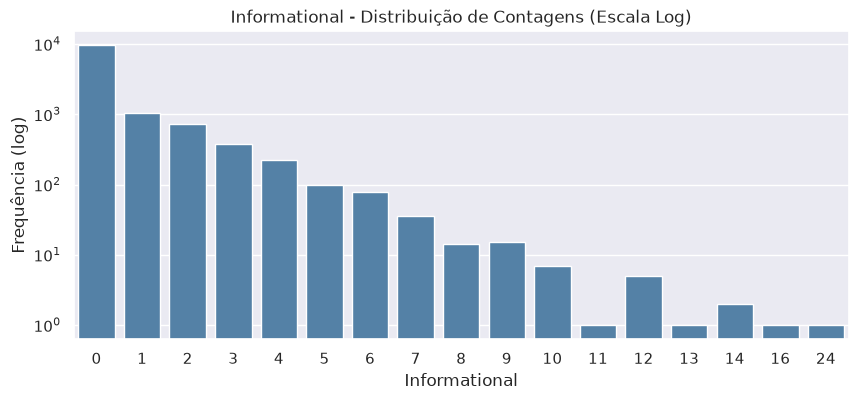

In [144]:
plt.figure(figsize=(10, 4))
ax = sns.countplot(x="Informational", data=df, color="steelblue")
ax.set_yscale("log")
plt.title("Informational - Distribuição de Contagens (Escala Log)")
plt.ylabel("Frequência (log)")
plt.show()

### Informational_Duration

In [145]:
col = df["Informational_Duration"].dropna()

In [146]:
col.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

count    12330.000000
mean        34.472398
std        140.749294
min          0.000000
1%           0.000000
5%           0.000000
25%          0.000000
50%          0.000000
75%          0.000000
95%        195.000000
99%        716.390000
max       2549.375000
Name: Informational_Duration, dtype: float64

In [147]:
skew = col.skew()
kurt = col.kurtosis()

q25 = col.quantile(0.25)
q75 = col.quantile(0.75)
iqr = q75 - q25

print(f"Skewness: {skew:.4f}\nKurtosis: {kurt:.4f}\nIQR: {iqr:.4f}")

Skewness: 7.5792
Kurtosis: 76.3169
IQR: 0.0000


In [148]:
limite_inferior = q25 - 1.5 * iqr
limite_superior = q75 + 1.5 * iqr

outliers = df[(col < limite_inferior) | (col > limite_superior)]
print(f"Outliers: {len(outliers)} linhas ({len(outliers) / len(df) * 100:.2f}%)")

Outliers: 2405 linhas (19.51%)


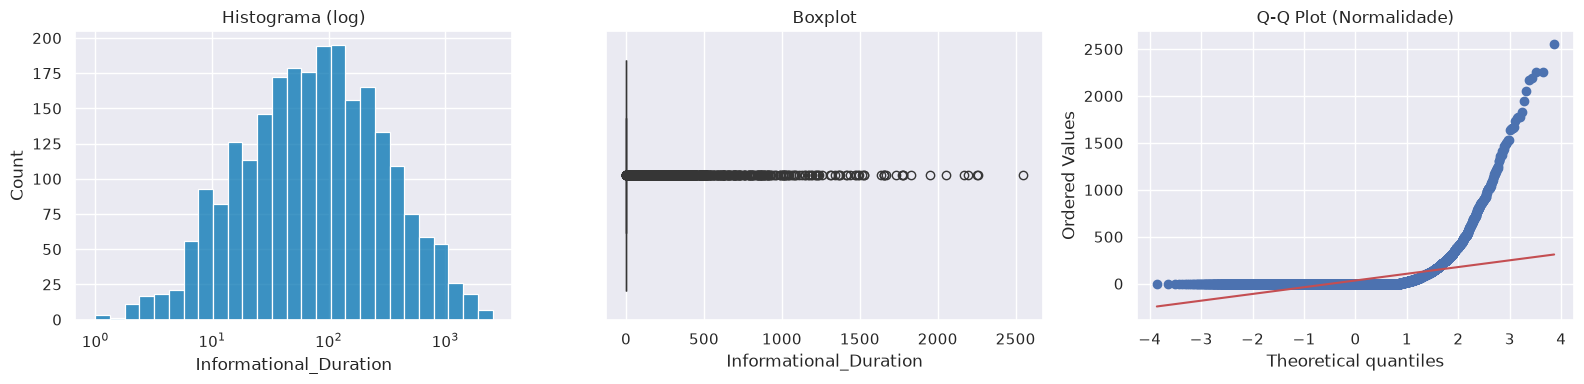

In [149]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(data=df, x=col, ax=axes[0], log_scale=True)
axes[0].set_title("Histograma (log)")

sns.boxplot(x=col, ax=axes[1])
axes[1].set_title("Boxplot")

stats.probplot(col, dist="norm", plot=axes[2])
axes[2].set_title("Q-Q Plot (Normalidade)")

plt.tight_layout()
plt.show()

### ProductRelated

In [150]:
df["ProductRelated"].value_counts(normalize=True)

ProductRelated
1      0.050446
2      0.037713
3      0.037145
4      0.032766
6      0.032117
         ...   
378    0.000081
254    0.000081
183    0.000081
210    0.000081
192    0.000081
Name: proportion, Length: 311, dtype: float64

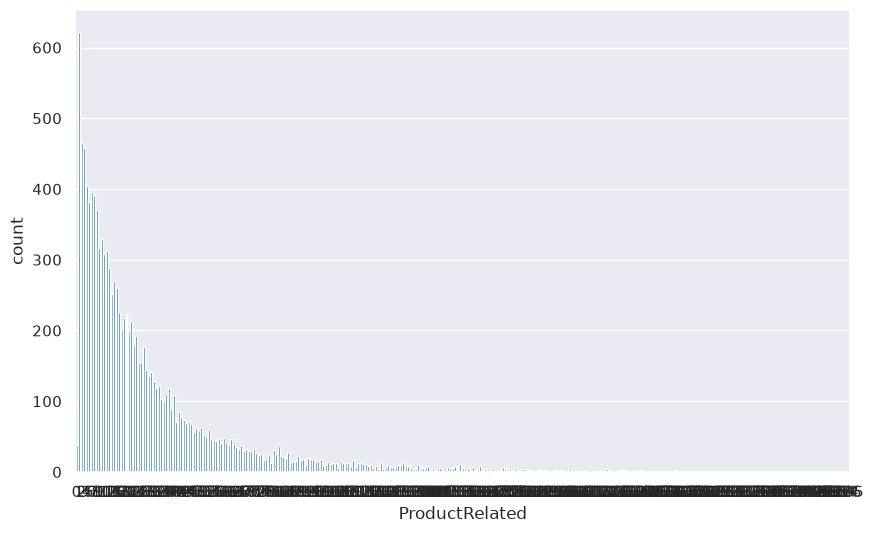

In [151]:
plt.figure(figsize=(10, 6))
sns.countplot(x="ProductRelated", data=df)
plt.show()

In [152]:
zero_rate = (df["ProductRelated"] == 0).mean() * 100
positive_vals = df.loc[df["ProductRelated"] > 0, "ProductRelated"]

print(f"Taxa de zeros: {zero_rate:.2f}%")
print(
    f"Resumo (> 0): Mediana={positive_vals.median()}, P90={positive_vals.quantile(0.90)}, Max={positive_vals.max()}"
)

Taxa de zeros: 0.31%
Resumo (> 0): Mediana=18.0, P90=74.0, Max=705


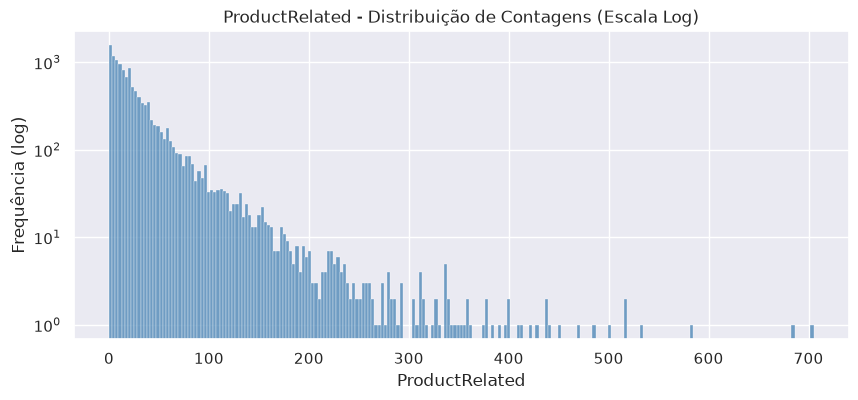

In [153]:
plt.figure(figsize=(10, 4))
ax = sns.histplot(x="ProductRelated", data=df, color="steelblue")
ax.set_yscale("log")
plt.title("ProductRelated - Distribuição de Contagens (Escala Log)")
plt.ylabel("Frequência (log)")
plt.show()

In [154]:
df_extreme = df[df["ProductRelated"] > 200]

print("Taxa de conversão em sessões extremas:")
print(df_extreme["Revenue"].value_counts(normalize=True))

avg_time_per_product = (
    df_extreme["ProductRelated_Duration"] / df_extreme["ProductRelated"]
)
print(
    f"\nTempo médio por página de produto (mediana): {avg_time_per_product.median():.2f} segundos"
)

print("\nTipo de visitante nessas sessões:")
print(df_extreme["VisitorType"].value_counts())

Taxa de conversão em sessões extremas:
Revenue
False    0.635135
True     0.364865
Name: proportion, dtype: float64

Tempo médio por página de produto (mediana): 36.09 segundos

Tipo de visitante nessas sessões:
VisitorType
Returning_Visitor    146
New_Visitor            1
Other                  1
Name: count, dtype: int64


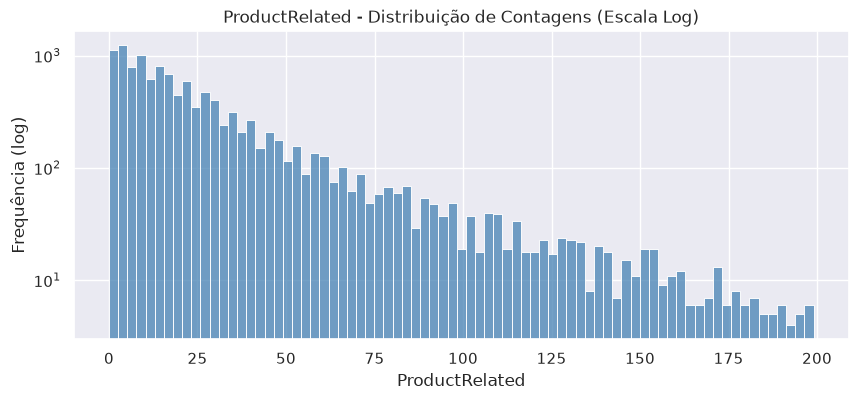

In [155]:
plt.figure(figsize=(10, 4))
ax = sns.histplot(
    x="ProductRelated", data=df[df["ProductRelated"] < 200], color="steelblue"
)
ax.set_yscale("log")
plt.title("ProductRelated - Distribuição de Contagens (Escala Log)")
plt.ylabel("Frequência (log)")
plt.show()

### ProductRelated_Duration

In [156]:
col = df["ProductRelated_Duration"].dropna()

In [157]:
col.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

count    12330.000000
mean      1194.746220
std       1913.669288
min          0.000000
1%           0.000000
5%           0.000000
25%        184.137500
50%        598.936905
75%       1464.157214
95%       4300.289077
99%       8701.142697
max      63973.522230
Name: ProductRelated_Duration, dtype: float64

In [158]:
skew = col.skew()
kurt = col.kurtosis()

q25 = col.quantile(0.25)
q75 = col.quantile(0.75)
iqr = q75 - q25

print(f"Skewness: {skew:.4f}\nKurtosis: {kurt:.4f}\nIQR: {iqr:.4f}")

Skewness: 7.2632
Kurtosis: 137.1742
IQR: 1280.0197


In [159]:
limite_inferior = q25 - 1.5 * iqr
limite_superior = q75 + 1.5 * iqr

outliers = df[(col < limite_inferior) | (col > limite_superior)]
print(f"Outliers: {len(outliers)} linhas ({len(outliers) / len(df) * 100:.2f}%)")

Outliers: 961 linhas (7.79%)


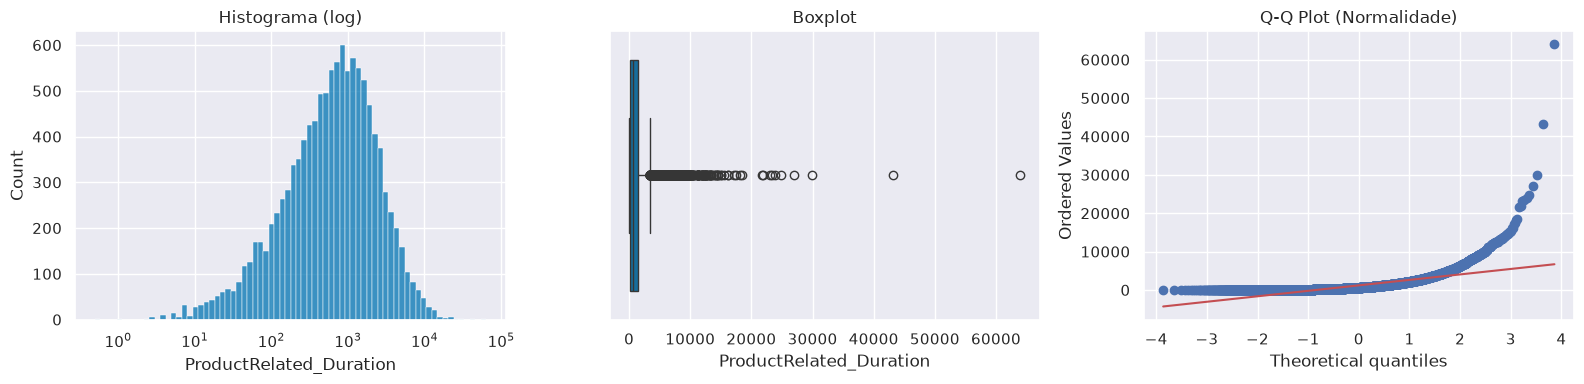

In [160]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(data=df, x=col, ax=axes[0], log_scale=True)
axes[0].set_title("Histograma (log)")

sns.boxplot(x=col, ax=axes[1])
axes[1].set_title("Boxplot")

stats.probplot(col, dist="norm", plot=axes[2])
axes[2].set_title("Q-Q Plot (Normalidade)")

plt.tight_layout()
plt.show()

### BounceRates

In [161]:
print(f"Taxa de Bounce zero: {(df['BounceRates'] == 0).mean() * 100:.2f}%")
print(
    f"Taxa no valor máximo: {(df['BounceRates'] == df['BounceRates'].max()).mean() * 100:.2f}%"
)

Taxa de Bounce zero: 44.75%
Taxa no valor máximo: 5.68%


### ExitRates

In [162]:
print(f"Taxa de Exit zero: {(df['ExitRates'] == 0).mean() * 100:.2f}%")
print(
    f"Taxa no valor máximo: {(df['ExitRates'] == df['ExitRates'].max()).mean() * 100:.2f}%"
)

Taxa de Exit zero: 0.62%
Taxa no valor máximo: 5.76%


### PageValues

In [163]:
print(f"Taxa de PageValues zero: {(df['PageValues'] == 0).mean() * 100:.2f}%")
print(
    f"Taxa no valor máximo: {(df['PageValues'] == df['PageValues'].max()).mean() * 100:.2f}%"
)

Taxa de PageValues zero: 77.86%
Taxa no valor máximo: 0.01%


### SpecialDay

In [164]:
special_day_counts = pd.DataFrame(
    {
        "contagem": df["SpecialDay"].value_counts().sort_index(),
        "percentual": df["SpecialDay"].value_counts(normalize=True).sort_index() * 100,
    }
)
print(special_day_counts)

            contagem  percentual
SpecialDay                      
0.0            11079   89.854015
0.2              178    1.443633
0.4              243    1.970803
0.6              351    2.846715
0.8              325    2.635848
1.0              154    1.248986


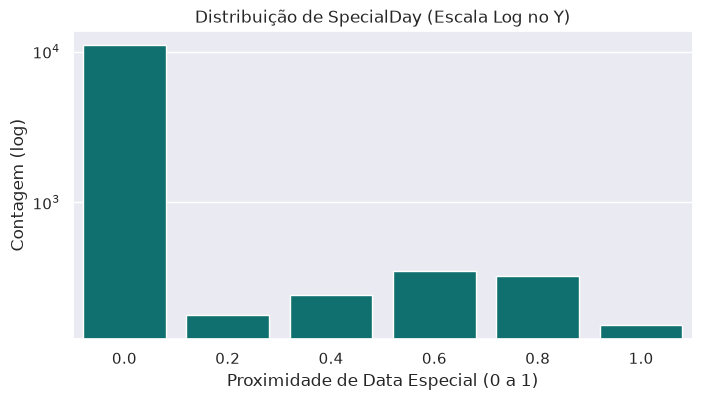

In [165]:
plt.figure(figsize=(8, 4))
ax = sns.countplot(x="SpecialDay", data=df, color="teal")
ax.set_yscale("log")
plt.title("Distribuição de SpecialDay (Escala Log no Y)")
plt.ylabel("Contagem (log)")
plt.xlabel("Proximidade de Data Especial (0 a 1)")
plt.show()

In [166]:
pd.crosstab(df["Month"], df["SpecialDay"] > 0)

SpecialDay,False,True
Month,,
2,105,79
3,1907,0
5,2192,1172
6,288,0
7,432,0
8,433,0
9,448,0
10,549,0
11,2998,0


In [167]:
df.groupby("SpecialDay")["Revenue"].agg(["count", "mean"])

,count,mean
SpecialDay,,
0.0,11079,0.165268
0.2,178,0.078652
0.4,243,0.053498
0.6,351,0.082621
0.8,325,0.033846
1.0,154,0.064935


### Month

In [168]:
month_summary = df.groupby("Month")["Revenue"].agg(["count", "mean"])
print(month_summary)

       count      mean
Month                 
2        184  0.016304
3       1907  0.100682
5       3364  0.108502
6        288  0.100694
7        432  0.152778
8        433  0.175520
9        448  0.191964
10       549  0.209472
11      2998  0.253502
12      1727  0.125072


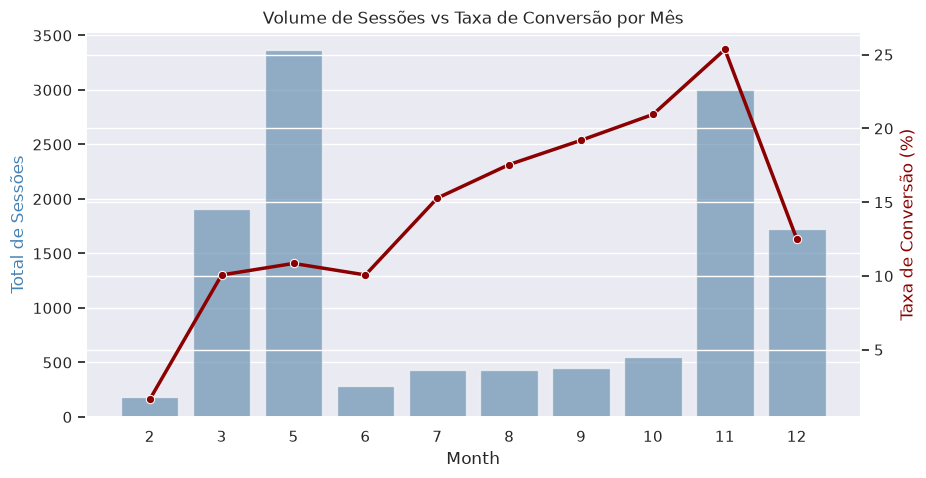

In [169]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax1 = plt.subplots(figsize=(10, 5))

sns.barplot(
    x=month_summary.index,
    y=month_summary["count"],
    ax=ax1,
    color="steelblue",
    alpha=0.6,
)
ax1.set_ylabel("Total de Sessões", color="steelblue")

ax2 = ax1.twinx()
sns.lineplot(
    x=range(len(month_summary)),
    y=month_summary["mean"] * 100,
    ax=ax2,
    color="darkred",
    marker="o",
    linewidth=2.5,
)
ax2.set_ylabel("Taxa de Conversão (%)", color="darkred")
plt.title("Volume de Sessões vs Taxa de Conversão por Mês")
plt.show()

### OperatingSystems, Browser, Region

In [170]:
for col in ["OperatingSystems", "Browser", "Region"]:
    counts = df[col].value_counts(normalize=True) * 100
    top_3_pct = counts.iloc[:3].sum()
    print(f"\n--- {col} (Cardinalidade: {df[col].nunique()}) ---")
    print(f"Top 3 categorias concentram: {top_3_pct:.1f}% da base")
    print(counts.head(5).round(2).to_dict())


--- OperatingSystems (Cardinalidade: 8) ---
Top 3 categorias concentram: 95.2% da base
{2: 53.54, 1: 20.97, 3: 20.72, 4: 3.88, 8: 0.64}

--- Browser (Cardinalidade: 13) ---
Top 3 categorias concentram: 90.5% da base
{2: 64.57, 1: 19.97, 4: 5.97, 5: 3.79, 6: 1.41}

--- Region (Cardinalidade: 9) ---
Top 3 categorias concentram: 67.8% da base
{1: 38.77, 3: 19.49, 4: 9.59, 2: 9.21, 6: 6.53}


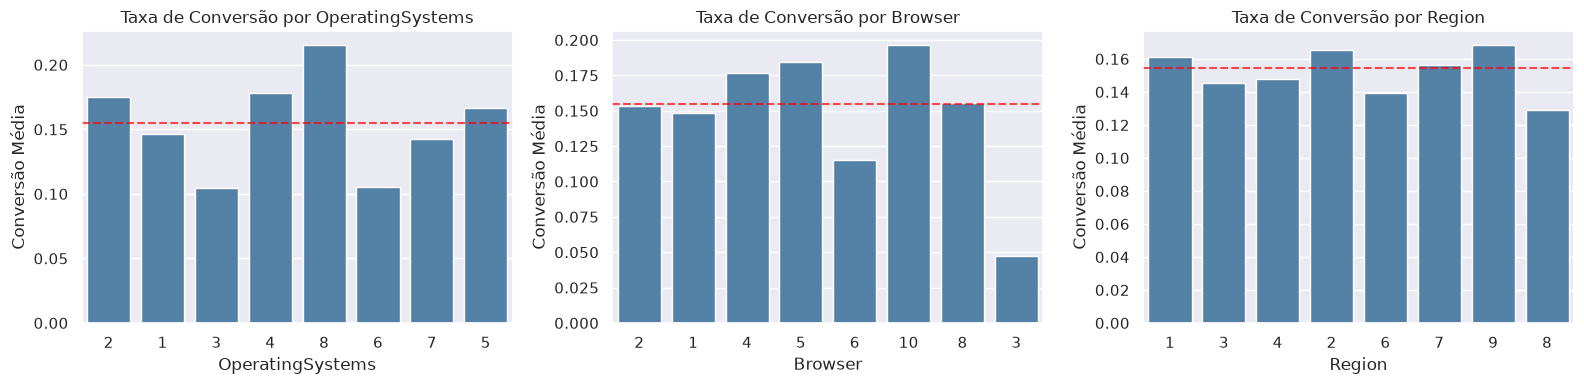

In [171]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, ["OperatingSystems", "Browser", "Region"]):
    # Calcula taxa de conversão ordenada por categoria
    order = df[col].value_counts().index[:8]  # pega até os 8 mais frequentes
    sns.barplot(
        x=col,
        y="Revenue",
        data=df[df[col].isin(order)],
        order=order,
        ax=ax,
        color="steelblue",
        errorbar=None,
    )
    ax.set_title(f"Taxa de Conversão por {col}")
    ax.set_ylabel("Conversão Média")
    # Linha pontilhada da média global para referência
    ax.axhline(df["Revenue"].mean(), color="red", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

### TrafficType

In [172]:
# Contagem e percentual acumulado
traffic_counts = pd.DataFrame(
    {
        "sessões": df["TrafficType"].value_counts(),
        "percentual": df["TrafficType"].value_counts(normalize=True) * 100,
    }
).sort_values("sessões", ascending=False)

traffic_counts["acumulado"] = traffic_counts["percentual"].cumsum()
print(traffic_counts.head(10))

             sessões  percentual  acumulado
TrafficType                                
2               3913   31.735604  31.735604
1               2451   19.878345  51.613950
3               2052   16.642336  68.256285
4               1069    8.669911  76.926196
13               738    5.985401  82.911598
10               450    3.649635  86.561233
6                444    3.600973  90.162206
8                343    2.781833  92.944039
5                260    2.108678  95.052717
11               247    2.003244  97.055961


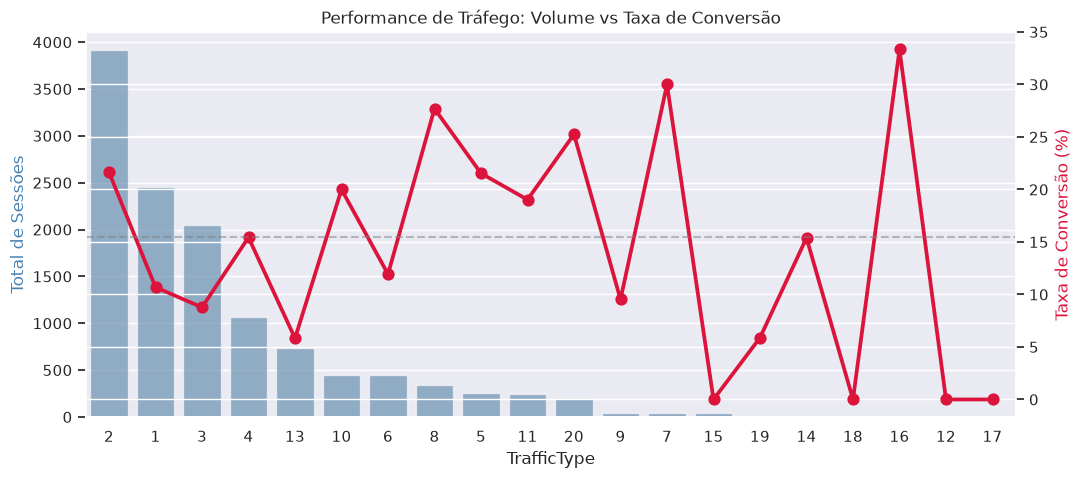

In [173]:
import matplotlib.pyplot as plt
import seaborn as sns

traffic_perf = (
    df.groupby("TrafficType")
    .agg(total=("Revenue", "count"), conversion_rate=("Revenue", "mean"))
    .sort_values("total", ascending=False)
)

fig, ax1 = plt.subplots(figsize=(12, 5))

# Volume por canal (ordem decrescente de tráfego)
sns.barplot(
    x=traffic_perf.index.astype(str),
    y=traffic_perf["total"],
    ax=ax1,
    color="steelblue",
    alpha=0.6,
    order=traffic_perf.index.astype(str),
)
ax1.set_ylabel("Total de Sessões", color="steelblue")
ax1.set_xlabel("TrafficType")

# Linha de conversão
ax2 = ax1.twinx()
sns.pointplot(
    x=traffic_perf.index.astype(str),
    y=traffic_perf["conversion_rate"] * 100,
    ax=ax2,
    color="crimson",
    order=traffic_perf.index.astype(str),
)
ax2.set_ylabel("Taxa de Conversão (%)", color="crimson")
ax2.axhline(
    df["Revenue"].mean() * 100,
    color="gray",
    linestyle="--",
    alpha=0.5,
    label="Média Global",
)

plt.title("Performance de Tráfego: Volume vs Taxa de Conversão")
plt.show()

### VisitorType

In [174]:
visitor_counts = pd.DataFrame(
    {
        "contagem": df["VisitorType"].value_counts(),
        "percentual": df["VisitorType"].value_counts(normalize=True) * 100,
    }
)
print(visitor_counts)

                   contagem  percentual
VisitorType                            
Returning_Visitor     10551   85.571776
New_Visitor            1694   13.738848
Other                    85    0.689376


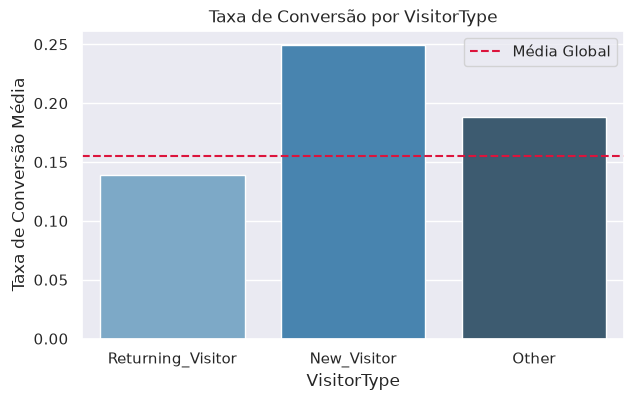

                   count      mean
VisitorType                       
New_Visitor         1694  0.249115
Other                 85  0.188235
Returning_Visitor  10551  0.139323


In [175]:
plt.figure(figsize=(7, 4))
ax = sns.barplot(
    x="VisitorType",
    y="Revenue",
    data=df,
    hue="VisitorType",
    palette="Blues_d",
    errorbar=None,
)
ax.axhline(df["Revenue"].mean(), color="crimson", linestyle="--", label="Média Global")
plt.title("Taxa de Conversão por VisitorType")
plt.ylabel("Taxa de Conversão Média")
plt.legend()
plt.show()

print(df.groupby("VisitorType")["Revenue"].agg(["count", "mean"]))

### Weekend

In [176]:
weekend_perf = df.groupby("Weekend")["Revenue"].agg(
    total_sessoes="count", compras="sum", taxa_conversao="mean"
)
print(weekend_perf)

         total_sessoes  compras  taxa_conversao
Weekend                                        
False             9462     1409        0.148911
True              2868      499        0.173989


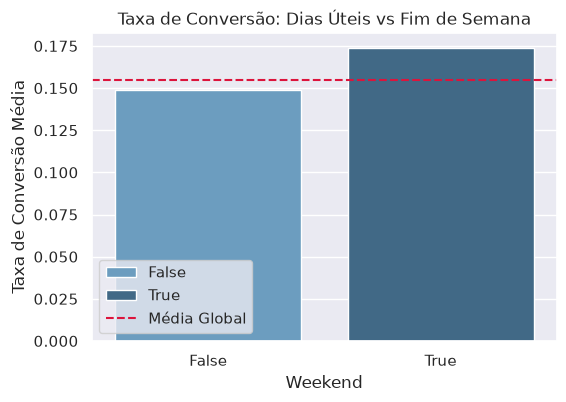

In [177]:
plt.figure(figsize=(6, 4))
ax = sns.barplot(
    x="Weekend", y="Revenue", data=df, hue="Weekend", palette="Blues_d", errorbar=None
)
ax.axhline(df["Revenue"].mean(), color="crimson", linestyle="--", label="Média Global")
plt.title("Taxa de Conversão: Dias Úteis vs Fim de Semana")
plt.ylabel("Taxa de Conversão Média")
plt.legend()
plt.show()

## Análise Multivariada

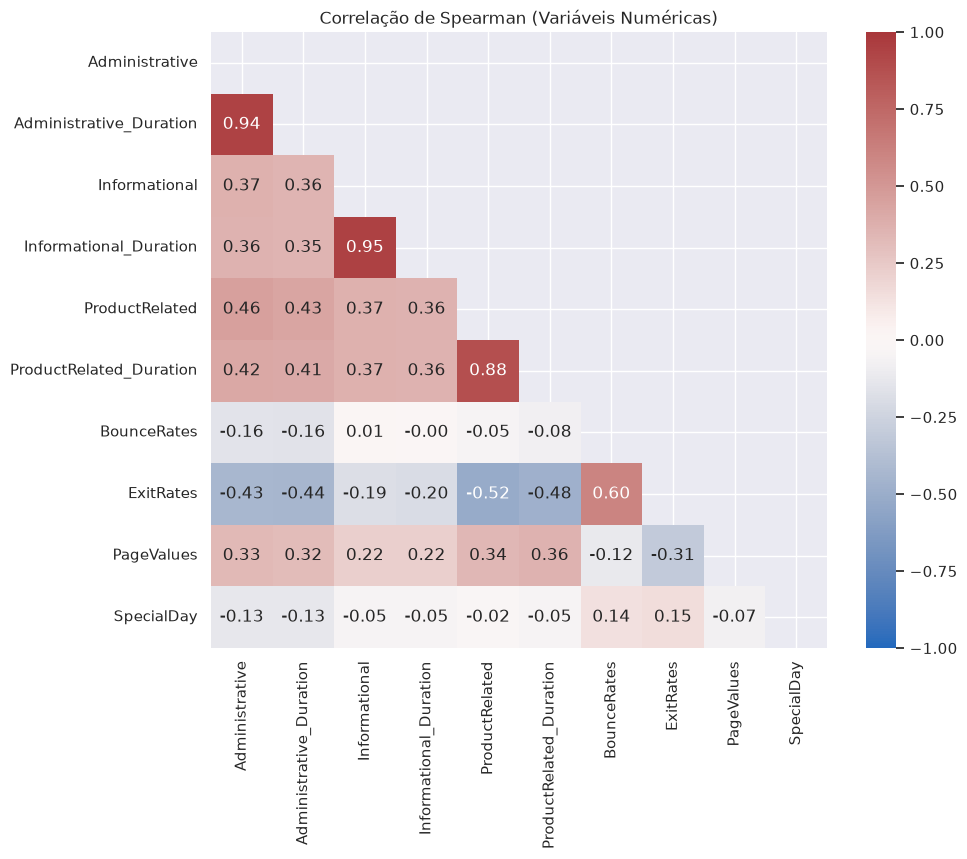

In [178]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

num_cols = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay",
]

corr_spearman = df[num_cols].corr(method="spearman")

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_spearman, dtype=bool))
sns.heatmap(
    corr_spearman,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    vmin=-1,
    vmax=1,
    square=True,
)
plt.title("Correlação de Spearman (Variáveis Numéricas)")
plt.show()

In [179]:
# Tabela rápida de medianas e IQR por status de Revenue
summary_bivariate = df.groupby("Revenue")[num_cols].median().T
summary_bivariate.columns = ["Mediana_Nao_Comprou (0)", "Mediana_Comprou (1)"]
print(summary_bivariate)

                         Mediana_Nao_Comprou (0)  Mediana_Comprou (1)
Administrative                          0.000000             2.000000
Administrative_Duration                 0.000000            52.366667
Informational                           0.000000             0.000000
Informational_Duration                  0.000000             0.000000
ProductRelated                         16.000000            29.000000
ProductRelated_Duration               510.190000          1109.906250
BounceRates                             0.004255             0.000000
ExitRates                               0.028571             0.016000
PageValues                              0.000000            16.758134
SpecialDay                              0.000000             0.000000


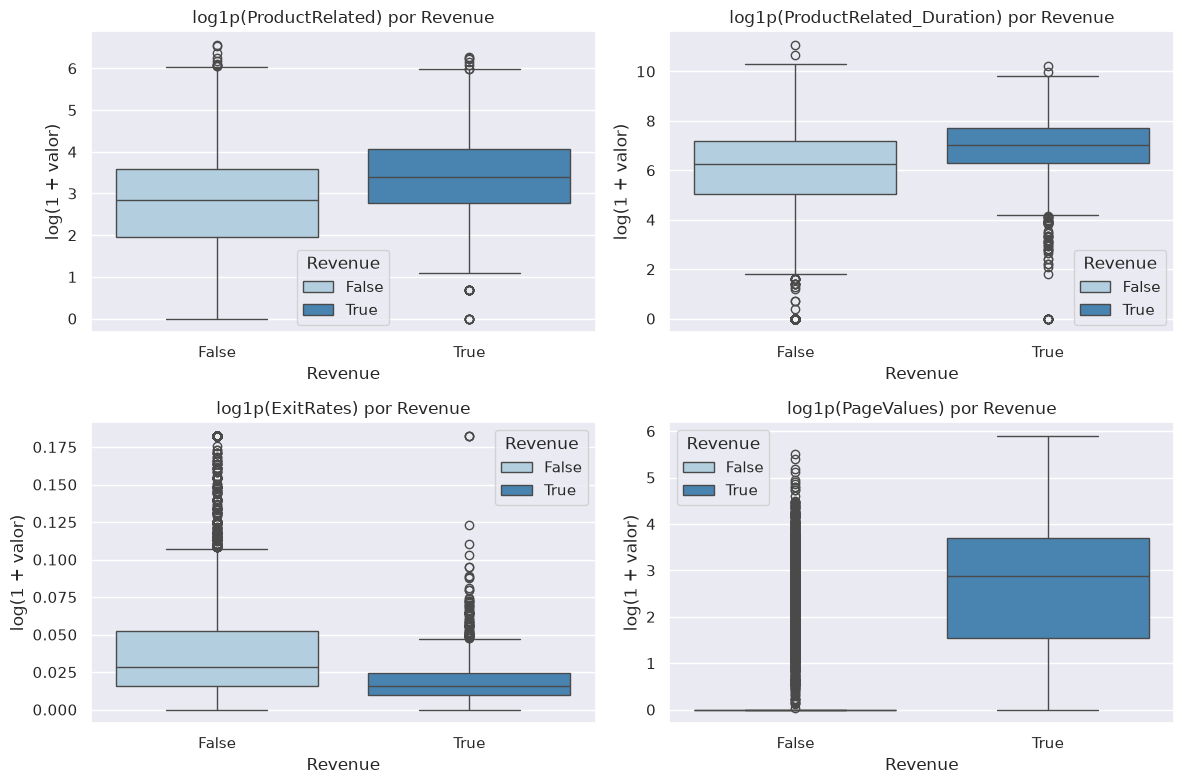

In [180]:
key_num_features = [
    "ProductRelated",
    "ProductRelated_Duration",
    "ExitRates",
    "PageValues",
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, col in zip(axes, key_num_features):
    # Se tiver valores nulos ou zeros, log1p segura a onda
    sns.boxplot(
        x="Revenue", y=np.log1p(df[col]), data=df, ax=ax, hue="Revenue", palette="Blues"
    )
    ax.set_title(f"log1p({col}) por Revenue")
    ax.set_ylabel("log(1 + valor)")

plt.tight_layout()
plt.show()

In [181]:
cat_cols = ["Month", "VisitorType", "Weekend"]

for col in cat_cols:
    ct = pd.crosstab(df[col], df["Revenue"], normalize="index") * 100
    print(f"\n--- {col} vs Revenue (%) ---")
    print(ct.round(2))


--- Month vs Revenue (%) ---
Revenue  False  True 
Month                
2        98.37   1.63
3        89.93  10.07
5        89.15  10.85
6        89.93  10.07
7        84.72  15.28
8        82.45  17.55
9        80.80  19.20
10       79.05  20.95
11       74.65  25.35
12       87.49  12.51

--- VisitorType vs Revenue (%) ---
Revenue            False  True 
VisitorType                    
New_Visitor        75.09  24.91
Other              81.18  18.82
Returning_Visitor  86.07  13.93

--- Weekend vs Revenue (%) ---
Revenue  False  True 
Weekend              
False    85.11  14.89
True     82.60  17.40


In [182]:
for col in ["Month", "VisitorType", "TrafficType", "OperatingSystems", "Weekend"]:
    contingency = pd.crosstab(df[col], df["Revenue"])
    chi2, p, dof, _ = stats.chi2_contingency(contingency)
    print(
        f"{col:20s} -> p-valor: {p:.4e} {'(Significativo)' if p < 0.05 else '(Não significativo)'}"
    )

Month                -> p-valor: 2.2388e-77 (Significativo)
VisitorType          -> p-valor: 4.2699e-30 (Significativo)
TrafficType          -> p-valor: 1.6527e-67 (Significativo)
OperatingSystems     -> p-valor: 1.4161e-13 (Significativo)
Weekend              -> p-valor: 1.2663e-03 (Significativo)


In [183]:
def cramers_v(contingency_table):
    chi2 = stats.chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    r, k = contingency_table.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))


cols = [
    "Month",
    "TrafficType",
    "VisitorType",
    "OperatingSystems",
    "Browser",
    "Region",
    "Weekend",
]

cramer_results = {}
for col in cols:
    ct = pd.crosstab(df[col], df["Revenue"])
    cramer_results[col] = cramers_v(ct)

# Tabela ordenada por força de associação
res_df = pd.DataFrame.from_dict(
    cramer_results, orient="index", columns=["Cramers_V"]
).sort_values(by="Cramers_V", ascending=False)
print(res_df.round(4))

                  Cramers_V
Month                0.1767
TrafficType          0.1740
VisitorType          0.1047
OperatingSystems     0.0780
Browser              0.0474
Weekend              0.0290
Region               0.0274
